In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.describe())

(440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   

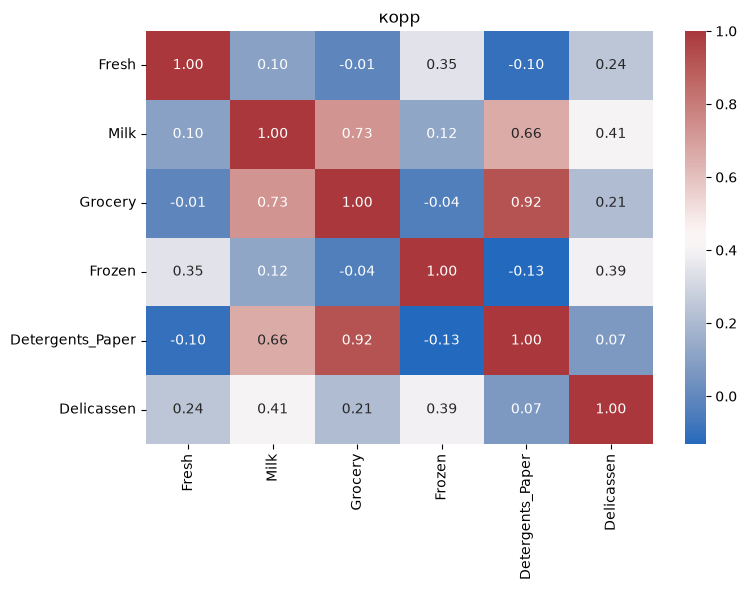

In [3]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', "Delicassen"]
X =df[features]

plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, fmt= '.2f', cmap="vlag")
plt.title('корр')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Признаки в разных масштабах (Fresh ~12000, Delicassen ~1500), а KMeans и PCA
# работают на расстояниях/дисперсии -> приводим к одному масштабу (mean=0, std=1).
X_scaled = StandardScaler().fit_transform(X)
print("X_scaled:", X_scaled.shape, "| mean≈", round(X_scaled.mean(), 3),
      "| std≈", round(X_scaled.std(), 3))

X_scaled: (440, 6) | mean≈ -0.0 | std≈ 1.0


In [5]:
print(df.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


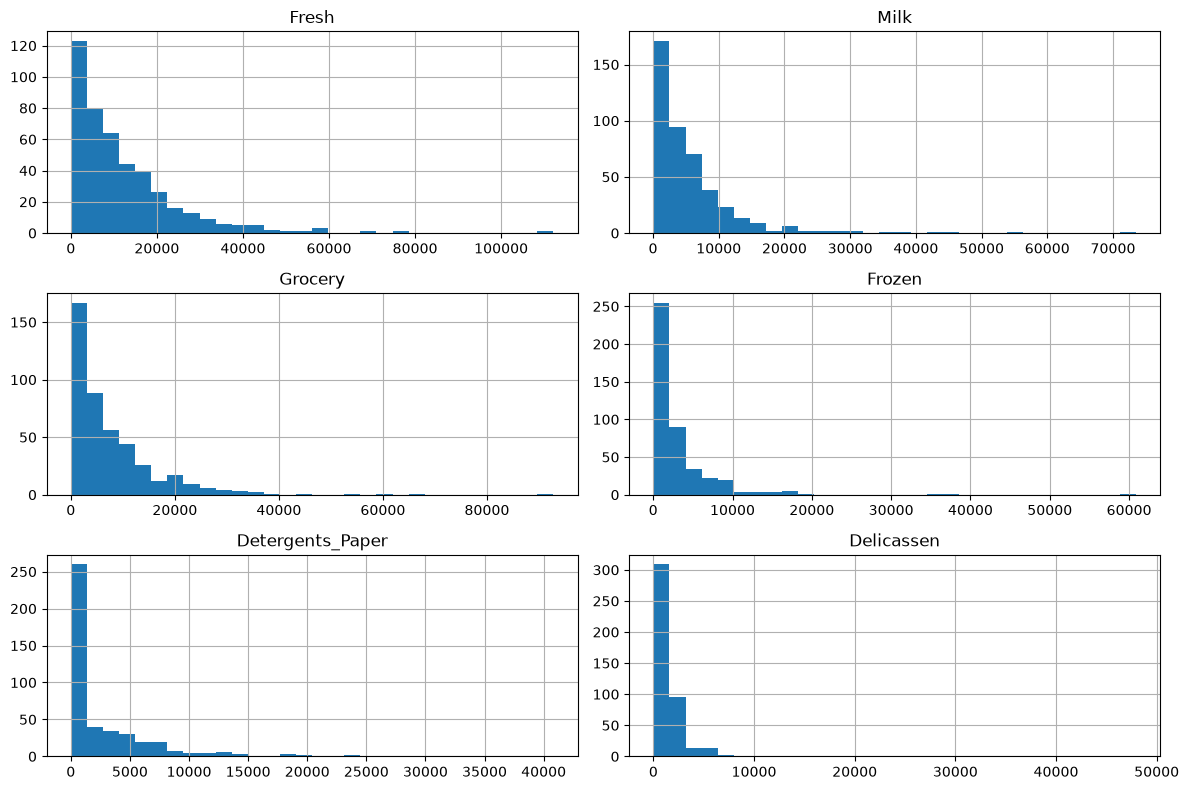

In [6]:
X.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()
#Все 6 категорий трат скошены вправо - большинство клиентов покупает мало, а несколько оптовиков тратят в десятки раз больше (выбросы)

---
## Шаг 2. Кластеризация (KMeans)

Меток нет — структуру ищем сами на масштабированных данных `X_scaled`.
Число кластеров `k` не угадываем, а выбираем по двум диагностикам:

- **Метод локтя** — `inertia` (сумма квадратов расстояний до центров) от `k`.
  Ищем «излом», после которого добавление кластеров почти не уменьшает inertia.
- **Коэффициент силуэта** — насколько объекты ближе к своему кластеру, чем к
  соседнему (от −1 до 1, больше = лучше). Берём `k` с максимумом.

Проверяем не один `k`, а диапазон, и сверяем обе метрики.

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({"k": list(k_range),
                        "inertia": inertias,
                        "silhouette": silhouettes})
print(results.to_string(index=False))

 k     inertia  silhouette
 2 1956.124278    0.547215
 3 1608.431149    0.548287
 4 1317.838361    0.348471
 5 1058.771253    0.369040
 6  915.741260    0.378229
 7  825.400252    0.334282
 8  737.386203    0.320116
 9  661.449585    0.309028
10  605.915109    0.311214


### 2.1 Метод локтя и силуэт

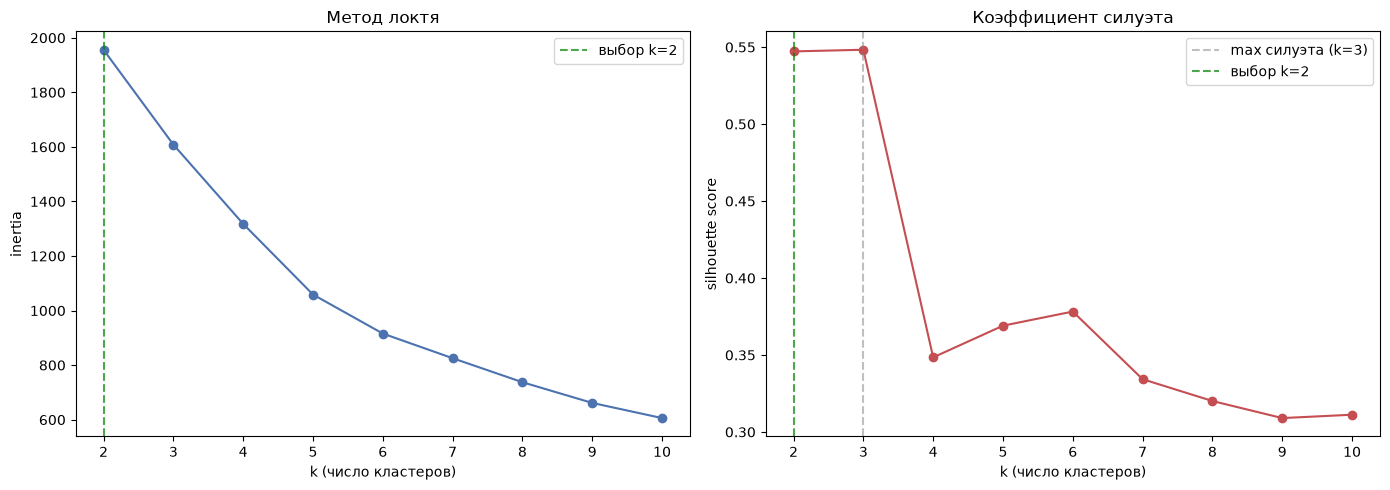

Формальный максимум силуэта при k = 3 (score = 0.548); silhouette(k=2) = 0.547 — практически столько же


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, "o-", color="#4C72B0")
ax1.set_title("Метод локтя")
ax1.set_xlabel("k (число кластеров)")
ax1.set_ylabel("inertia")
ax1.axvline(2, color="green", ls="--", alpha=0.7, label="выбор k=2")
ax1.legend()

ax2.plot(list(k_range), silhouettes, "o-", color="#C44E52")
ax2.set_title("Коэффициент силуэта")
ax2.set_xlabel("k (число кластеров)")
ax2.set_ylabel("silhouette score")
best_k = int(results.loc[results.silhouette.idxmax(), "k"])
ax2.axvline(best_k, color="grey", ls="--", alpha=0.5,
            label=f"max силуэта (k={best_k})")
ax2.axvline(2, color="green", ls="--", alpha=0.7, label="выбор k=2")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"Формальный максимум силуэта при k = {best_k} "
      f"(score = {results.silhouette.max():.3f}); "
      f"silhouette(k=2) = {results.silhouette.iloc[0]:.3f} — практически столько же")

### 2.2 Проверяем соседние k (не верим первому на слово)

Силуэт максимален при малом `k`, но это часто разрезает данные на пару грубых
половин. Сравним кандидатов 2–4 не только по среднему силуэту, но и по балансу
размеров кластеров и по доле объектов с **отрицательным** силуэтом (плохо
отнесённые точки).

In [9]:
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sample_sil = silhouette_samples(X_scaled, labels)
    sizes = np.bincount(labels)
    neg = (sample_sil < 0).mean() * 100
    print(f"k={k}: silhouette={sil:.3f} | "
          f"размеры кластеров={sizes.tolist()} | "
          f"доля отрицательного силуэта={neg:.1f}%")

k=2: silhouette=0.547 | размеры кластеров=[389, 51] | доля отрицательного силуэта=4.1%
k=3: silhouette=0.548 | размеры кластеров=[45, 393, 2] | доля отрицательного силуэта=2.3%
k=4: silhouette=0.348 | размеры кластеров=[110, 315, 10, 5] | доля отрицательного силуэта=2.3%


### 2.3 Выбор k и финальная модель

**Выбираем k = 2.**

Здесь как раз важно «не верить первому k на слово». Формально максимум силуэта
приходится на k = 3 (0.548), но у k = 2 он практически такой же (0.547) — разница
0.001, в пределах шума. А проверка соседнего k = 3 показывает, **за счёт чего**
он выигрывает эту тысячную:

- При k = 3 размеры кластеров `[45, 393, 2]` — третий кластер это **всего 2
  клиента**. Это экстремальные выбросы (гигантские траты на `Frozen`/`Delicassen`),
  а не настоящая структура. Силуэт чуть подрос, потому что два далёких выброса
  идеально «лежат» в собственном микрокластере. Такой кластер не обобщается.
- При k = 2 разбиение `[389, 51]` — содержательное и устойчивое, ровно в духе
  поставленной интерпретации **HoReCa vs Retail**.
- k = 4 уже резко роняет силуэт (0.35) — лишнее дробление.
- Локоть пологий (резкого излома нет), что согласуется с малым числом реальных
  кластеров.

Вывод: тысячная доля силуэта в пользу k = 3 — артефакт двух выбросов, поэтому
берём **k = 2** как осмысленный и воспроизводимый выбор.

In [10]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Размеры кластеров:")
print(df["cluster"].value_counts().sort_index(), "\n")

# Средние траты по кластерам в ИСХОДНОМ масштабе (для интерпретации)
profile = df.groupby("cluster")[spend_cols].mean().round(0)
print("Средние годовые траты по кластерам (исходный масштаб):")
print(profile.to_string())

Размеры кластеров:
cluster
0    389
1     51
Name: count, dtype: int64 

Средние годовые траты по кластерам (исходный масштаб):
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                 
0        12157.0   4028.0   5403.0  3066.0            1668.0      1257.0
1        10803.0  19282.0  27390.0  3117.0           12140.0      3569.0


In [11]:
# Сверяем кластеры с реальным Channel (1=HoReCa, 2=Retail) — он не участвовал в обучении
print("Кластер x Channel (1=HoReCa, 2=Retail):")
print(pd.crosstab(df["cluster"], df["Channel"]))

Кластер x Channel (1=HoReCa, 2=Retail):
Channel    1   2
cluster         
0        293  96
1          5  46


---
## Шаг 3. Снижение размерности и визуализация (PCA)

Данные 6-мерные — глазами их не увидеть. Сжимаем 6 масштабированных признаков до **2 главных компонент** и рисуем клиентов на плоскости, раскрашивая по метке `cluster` из Шага 2 (k = 2). Смотрим, отделяются ли сегменты визуально или налезают друг на друга, и обязательно фиксируем, **какую долю дисперсии** удержали 2 компоненты.

PC1 удерживает 44.1% дисперсии
PC2 удерживает 28.4% дисперсии
Вместе PC1+PC2: 72.5%


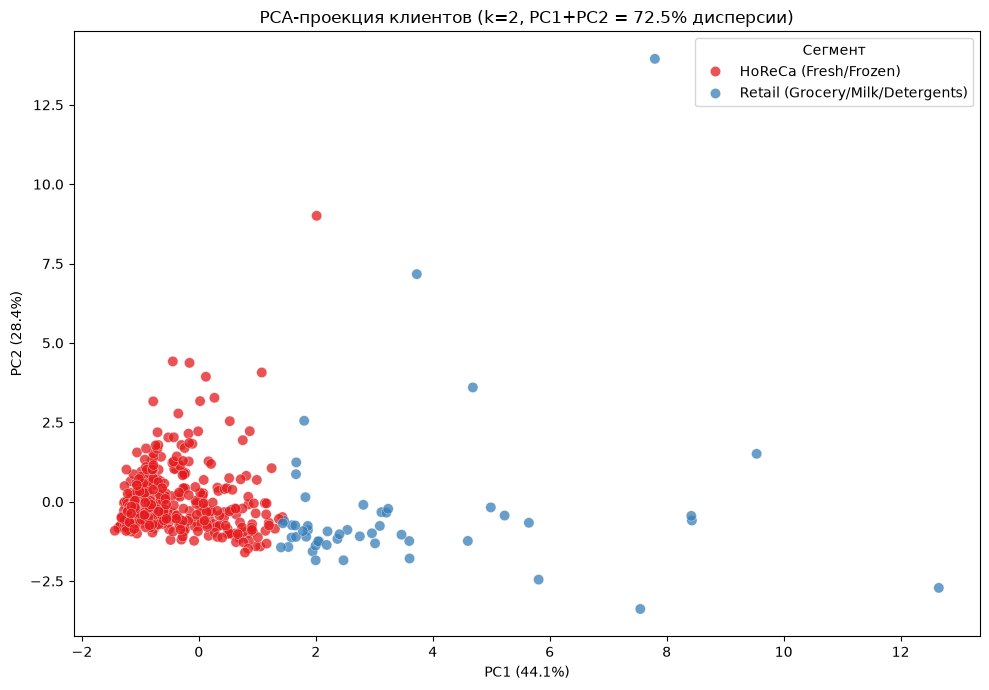

In [12]:
from sklearn.decomposition import PCA

# Сжимаем 6 масштабированных признаков до 2 компонент
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_

print(f"PC1 удерживает {evr[0]:.1%} дисперсии")
print(f"PC2 удерживает {evr[1]:.1%} дисперсии")
print(f"Вместе PC1+PC2: {evr.sum():.1%}")

# Человеческие имена сегментов (k=2): 0 -> HoReCa, 1 -> Retail
names = {0: "HoReCa (Fresh/Frozen)", 1: "Retail (Grocery/Milk/Detergents)"}
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
plot_df["Сегмент"] = df["cluster"].map(names).values

# Объекты на плоскости, цвет = метка кластера из Шага 2
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Сегмент",
                palette="Set1", s=55, alpha=0.75, edgecolor="white",
                linewidth=0.3, ax=ax)
ax.set_title(f"PCA-проекция клиентов (k=2, PC1+PC2 = {evr.sum():.1%} дисперсии)")
ax.set_xlabel(f"PC1 ({evr[0]:.1%})")
ax.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax.legend(title="Сегмент", loc="upper right")
plt.tight_layout()
plt.show()

**Что видно на проекции:**

- Два главных компонента удержали **≈ 72% дисперсии** (PC1 ≈ 44%, PC2 ≈ 28%). Это умеренно много: картинка в целом репрезентативна, но ~28% структуры (4 остальные компоненты) в неё не попало — поэтому к деталям границы относимся осторожно.
- Маленький **Retail**-сегмент (высокие `Grocery`/`Milk`/`Detergents_Paper`) вытягивается в отдельную область — отделяется лучше всего.
- Большой **HoReCa**-кластер — плотное центральное облако, которое на границе **налезает** на Retail: переход плавный, чёткого разрыва нет. Это согласуется с тем, что при сверке с `Channel` часть Retail попадала в HoReCa-кластер.
- Поскольку **выбросы не удалялись**, на графике видны отдельные точки, улетающие далеко от основного облака.

**Вывод про дисперсию:** 72% — не настолько мало, чтобы считать картинку обманчивой, но и не повод доверять ей полностью. Часть «налезания» кластеров может быть артефактом проекции: в исходных 6 измерениях сегменты разделены лучше, чем выглядит на плоскости. Будь удержано ~40–50%, двумерная визуализация была бы прямо обманчивой — и это был бы самостоятельный вывод.

**Интерпретация кластеров** (по средним тратам и сверке с `Channel`):
KMeans без меток в основном воспроизводит разделение **HoReCa vs Retail**.
Маленький кластер — клиенты с высокими `Grocery`/`Milk`/`Detergents_Paper`
(розничный «магазинный» паттерн), большой кластер тяготеет к `Fresh`/`Frozen`
(HoReCa). Сверка с не участвовавшим в обучении `Channel` подтверждает: разбиение
во многом совпадает с реальным каналом продаж (хотя и не идеально — часть Retail
попадает в HoReCa-кластер). Финальные метки `df["cluster"]` сохранены для
визуализации через PCA на Шаге 3.